# Projeto COP30 - Classificação de Projetos Sustentáveis


**Contexto:** Estamos em setembro de 2025, a poucos meses da **COP30 em Belém (novembro/2025)**. Este estudo aproveita o contexto da **COP30 em Belém (novembro/2025)**, e o desafio é identificar projetos que realmente tenham potencial de transformar compromissos climáticos em resultados concretos.

O objetivo é usar **ciência de dados** para apoiar decisões estratégicas: priorizar **projetos sustentáveis** com maior potencial de impacto ambiental e social, e boa viabilidade econômica/operacional, considerando múltiplos fatores ambientais, sociais, econômicos e tecnológicos.

**Tarefa:** Dado um *dataset* com indicadores ambientais, sociais, econômicos e tecnológicos, prever se um projeto é **Viável** ou **Não Viável** usando algoritmos de **classificação** (Árvore de Decisão, SVM e k-NN).




## Roteiro (CRISP-DM)

1. **Compreensão do Negócio:** critérios (CO2, água, circularidade, resiliência, maturirdade tecnológica, custos/retorno(.
2. **Compreensão dos Dados:** leitura, dicinário, qualidade,valores ausentes.
3. **Preparação dos Dados:** *encoding*, imputação, padronização (quando necessário).
4. **Modelagem:** Decision Tree, SVM, KNN (pipelines).
5. **Avaliação:** acurávia, precisão, recall, F1, matriz de confusão, ROC-AUC (binário).
6. **Reflexão/Deploy:** interpretação, trade-off e conexão com decisões COP30.

## Imports e verificação de versões

In [1]:
!pip install pandas numpy scikit-learn matplotlib joblib


In [2]:
import sys, platform                            # infos do Python/SO(documentação)
import numpy as np                              # cálculo numérico/vetorial
import pandas as pd                             # manipulação tabula(DataFrame)
import matplotlib.pyplot as plt                 # Gráficos

# Ferramentas de modelagem/validação do scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc
)
import joblib   # salvar/carregar modelos treinados

print(f"Python: {sys.version.split()[0]} | OS: {platform.system()} {platform.release()}\n")


Python: 3.11.11 | OS: Darwin 24.6.0



## 1.LEITURA DO DATASET — Compreensão dos Dados

**O que faz**: Lê o arquivo csv e cria um DataFrame.  
**Por que**: Precisamos inspecionar os dados antes de decidir como preparar e modelar.  


In [6]:

# Configuração
DATAPATH = "data/train.csv"

# Importação
df = pd.read_csv(DATAPATH)

# Mostra dimensões e primeiras linhas
print("Dimensão do dataset:", df.shape)
display(df.head(10))  # mostra 10 linhas

Dimensão do dataset: (10035, 5)


,desmatamento_pct,poluicao_mgL,dist_area_protegida_km,emissao_co2_ton,risco_socioambiental
0,24.0,14.1,14.6,491.6,0
1,12.3,20.1,4.1,1515.1,1
2,17.5,67.8,16.3,273.5,1
3,68.7,77.5,5.2,114.1,1
4,30.2,38.8,5.7,909.1,1
5,4.2,73.7,17.3,1369.9,1
6,30.7,64.6,12.0,820.1,1
7,35.7,98.9,8.5,1290.0,1
8,37.2,71.1,11.0,331.3,1
9,20.6,34.0,14.2,1356.2,1


## 1.1. (EDA Rápida) Exploração Inicial do Dataset
Objetivo: entender estrutura, tipos, estatísticas e valores ausentes para guiar preparação.

In [14]:
# =====================================================
# EDA Rápida (robusta) — evita erros quando não há colunas de certo tipo
# =====================================================

print("\n=== Info do DataFrame ===")
df.info()

# Identificar listas de colunas por tipo
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nDetectadas:")
print("• Numéricas:", num_cols if len(num_cols) else "(nenhuma)")
print("• Categóricas:", cat_cols if len(cat_cols) else "(nenhuma)")

# Estatísticas de numéricas (se houver)
if len(num_cols):
    print("\n=== Estatísticas (numéricas) ===")
    display(df[num_cols].describe().T)
else:
    print("\n[AVISO] Não há colunas numéricas para descrever.")

# Estatísticas de categóricas (se houver)
if len(cat_cols):
    print("\n=== Estatísticas (categóricas) ===")
    # describe('all') em categóricas traz count, unique, top, freq
    display(df[cat_cols].describe().T)

    # (Opcional) Top categorias por coluna
    print("\n=== Principais categorias por coluna (top 5) ===")
    for c in cat_cols:
        print(f"\nColuna: {c}")
        display(df[c].value_counts(dropna=False).head(5).to_frame("freq"))
else:
    print("\n[AVISO] Não há colunas categóricas (object/category/bool) para descrever.")

# Valores ausentes (todas as colunas)
print("\n=== Valores ausentes por coluna ===")
na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts.to_frame("n_missing"))



=== Info do DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   desmatamento_pct        10035 non-null  float64
 1   poluicao_mgL            10035 non-null  float64
 2   dist_area_protegida_km  10035 non-null  float64
 3   emissao_co2_ton         10035 non-null  float64
 4   risco_socioambiental    10035 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 392.1 KB

Detectadas:
• Numéricas: ['desmatamento_pct', 'poluicao_mgL', 'dist_area_protegida_km', 'emissao_co2_ton', 'risco_socioambiental']
• Categóricas: (nenhuma)

=== Estatísticas (numéricas) ===


,count,mean,std,min,25%,50%,75%,max
desmatamento_pct,10035.0,33.180968,15.963052,4.2,22.783583,32.851298,44.441898,69.0
poluicao_mgL,10035.0,54.706081,23.721070,5.3,38.309138,55.398944,71.739164,99.6
dist_area_protegida_km,10035.0,11.054674,4.876046,1.0,7.662446,11.416774,14.798880,19.7
emissao_co2_ton,10035.0,998.906331,539.597237,114.1,491.600879,1032.297346,1449.583385,1979.2
risco_socioambiental,10035.0,0.916692,0.276362,0.0,1.000000,1.000000,1.000000,1.0



[AVISO] Não há colunas categóricas (object/category/bool) para descrever.

=== Valores ausentes por coluna ===


,n_missing
desmatamento_pct,0
poluicao_mgL,0
dist_area_protegida_km,0
emissao_co2_ton,0
risco_socioambiental,0


## Verificação do Balanceamento da Variável-Alvo

**Objetivo.** Entender a distribuição da variável-alvo `risco_socioambiental` (0/1) para decidir como avaliar e treinar os modelos.

**Leitura da média.** Para variáveis binárias (0/1), a **média** é igual à **proporção de 1**.  
- Ex.: média = 0,90 → ~90% dos casos são classe 1.

**Critério prático (regra de bolso).**  
- Se a **classe minoritária** tiver **< 20%** das amostras (proporção < 0,20), trataremos o problema como **desbalanceado**.  
- Em cenários desbalanceados, **acurácia** pode enganar; devemos priorizar **precision/recall/F1** e analisar a **matriz de confusão**.

**Decisões quando há desbalanceamento.**
- Usar **divisão estratificada** (train/test) para preservar as proporções.  
- Relatar **precision, recall e F1** por classe (não só acurácia).  
- Considerar:  
  - `class_weight="balanced"` (SVM, Árvore),  
  - técnicas de reamostragem (undersampling/oversampling) — opcional,  
  - ajustar limiar de decisão (threshold) — opcional,  
  - validação cruzada estratificada.

A seguir, checamos **contagens, proporções e média** e geramos um **gráfico** para inspecionar a distribuição.


## 1.2. Checar balanceamento da variável-alvo (0/1) 

=== Distribuição no dataset completo ===


,contagem,proporcao
risco_socioambiental,,
0,836,0.0833
1,9199,0.9167



Média da variável-alvo (proporção da classe 1): 0.9167
Classe minoritária — proporção: 0.0833
Desbalanceado?  SIM


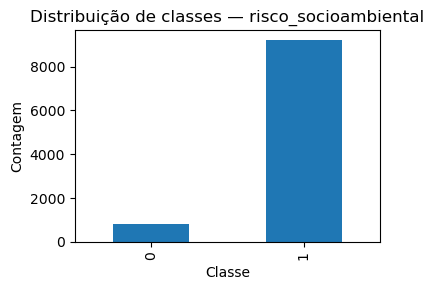


=== Proporções por classe (após split) ===


risco_socioambiental,0,1
proporcao_treino,0.083286,0.916714


risco_socioambiental,0,1
proporcao_teste,0.083361,0.916639



[Orientação] O conjunto está desbalanceado.
- Na avaliação, priorize Precision, Recall, F1 e Matriz de Confusão (não só Acurácia).
- Considerar class_weight='balanced' (em SVM/Árvore) e/ou reamostragem (SMOTE/undersampling).
- Usar validação cruzada estratificada.
- Reflitir sobre o custo de FP vs FN no seu contexto (COP30: mais grave aprovar projeto fraco ou reprovar um bom?).


In [16]:

# Objetivo:
#   - Definir o TARGET (nome da coluna-alvo) em um só lugar;
#   - Ver contagens e proporções das classes;
#   - Entender a média (em 0/1 = proporção de 1);
#   - Sinalizar desbalanceamento (regra de bolso);
#   - (Opcional) Fazer split estratificado e conferir proporções no treino/teste.
# Pré-requisitos:
#   - df já carregado (ex.: df = pd.read_csv(DATAPATH)).
# =====================================================



# 0) Definir alvo (boa prática) 
TARGET = "risco_socioambiental"   # nome da coluna que queremos prever (ajuste se necessário)
assert TARGET in df.columns, f"Coluna-alvo '{TARGET}' não encontrada em df.columns"  # checa se a coluna existe

# 1) Contagens e proporções no dataset completo 
counts = df[TARGET].value_counts().sort_index()              # conta quantos 0 e quantos 1; ordena por rótulo
props  = df[TARGET].value_counts(normalize=True).sort_index()# mesma contagem, mas em proporção (0 a 1), por classe

print("=== Distribuição no dataset completo ===")             # título amigável no console
# junta contagens e proporções em uma tabelinha para visualização
display(pd.DataFrame({"contagem": counts, "proporcao": props.round(4)}))

# 2) Média da variável-alvo (binária) 
mean_target = df[TARGET].mean()                              # em 0/1, a média = proporção da classe 1
print(f"\nMédia da variável-alvo (proporção da classe 1): {mean_target:.4f}")  # exibe com 4 casas decimais

# 3) Sinalizador simples de desbalanceamento 
minority_prop = props.min() if len(props) > 0 else np.nan    # pega a menor proporção (classe minoritária)
is_imbalanced = (minority_prop < 0.20)                       # regra de bolso: <20% é considerado desbalanceado
print(f"Classe minoritária — proporção: {minority_prop:.4f}")# mostra a proporção da classe menor
print("Desbalanceado? ", "SIM" if is_imbalanced else "NÃO")  # imprime um rótulo amigável

# 4) Visualização rápida 
plt.figure(figsize=(4,3))                                    # cria figura pequena (4x3 polegadas)
counts.plot(kind="bar")                                      # gráfico de barras com as contagens por classe
plt.title(f"Distribuição de classes — {TARGET}")             # título do gráfico
plt.xlabel("Classe")                                         # rótulo do eixo x
plt.ylabel("Contagem")                                       # rótulo do eixo y
plt.tight_layout()                                           # ajusta espaçamentos para não cortar textos
plt.show()                                                   # exibe o gráfico

# 5) (Opcional) Split estratificado 
X = df.drop(columns=[TARGET])                                 # X = todas as colunas exceto a variável-alvo
y = df[TARGET].copy()                                         # y = vetor/coluna com os rótulos (0/1)

# divide treino/teste mantendo proporções (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                      # dados de entrada (X) e rótulos (y)
    test_size=0.30,            # 30% para teste (ajuste para 0.2/0.25 se preferir)
    random_state=42,           # semente para reprodutibilidade (mesmo split toda vez)
    stratify=y                 # preserva a proporção das classes em treino e teste
)

print("\n=== Proporções por classe (após split) ===")         # título amigável para as proporções pós-split

# calcula e mostra a proporção por classe no TREINO; to_frame/T transfornam em tabela de 1 linha
proporcao_treino = y_train.value_counts(normalize=True).sort_index().to_frame("proporcao_treino").T
display(proporcao_treino)                                    # exibe a tabela de proporções do treino

# idem para o TESTE
proporcao_teste = y_test.value_counts(normalize=True).sort_index().to_frame("proporcao_teste").T
display(proporcao_teste)                                     # exibe a tabela de proporções do teste

# 6) Orientação textual (para o relatório/console) 
if is_imbalanced:
    # recomendações quando há desbalanceamento
    print(
        "\n[Orientação] O conjunto está desbalanceado.\n"
        "- Na avaliação, priorize Precision, Recall, F1 e Matriz de Confusão (não só Acurácia).\n"
        "- Considerar class_weight='balanced' (em SVM/Árvore) e/ou reamostragem (SMOTE/undersampling).\n"
        "- Usar validação cruzada estratificada.\n"
        "- Reflitir sobre o custo de FP vs FN no seu contexto (COP30: mais grave aprovar projeto fraco ou reprovar um bom?)."
    )
else:
    # recomendações quando o conjunto não está fortemente desbalanceado
    print(
        "\n[Orientação] O conjunto não parece fortemente desbalanceado.\n"
        "- Siga com avaliação padrão, mas ainda reporte métricas por classe e a matriz de confusão."
    )


# 2. Preparação dos dados

In [17]:
# Objetivo:
# - Separar X(preditoras/features) e y (alvo) usando o TARGET já definido.
# - Fazer split treino/teste com estratificação )dados desbalanceados).
# - Criar preprocessadores simples:
#      - Para Árvore: imputação (sem padronização).
#      - Para SVM/K-NN: imputação + padronizaçao (StandardScaler).
# Observação: não há colunas cetegóricas; logo, não usamos OneHotEncoder


#1) Separa X e y
y = df[TARGET].copy()                 # y = coluna-alvo (0/1), já definida em bloco anterior
X = df.drop(columns=[TARGET])         # X = todas as colunas exceto o TARGET

# 2) Sanidade: Garantir que tudo em X é numérico
# Por que: preprocessadores abaixo assumem somente colunas numéricas.

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()  # lista de colunas numéricas detectadas
assert set(num_cols) == set(X.columns), (
    "Foram encontradas colunas não numéricas em X. "
    "Converta-as para numéricas ou remova antes de prosseguir."
)

print("Colunas numéricas:", num_cols)


# 3) Split treino/teste com estratificação
SEED = 42          # semente p/ reprodutibilidade (definida no bloco 1; repito aqui por clareza local)
TEST_SIZE = 0.30   # 30% para teste (ajuste se preferir 0.2/0.25)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y         # preserva proporção das classes (importante em desbalanceamento)
)

print(f"\nDimensões -> X_train: {X_train.shape} | X_test: {X_test.shape} | y_train: {y_train.shape} | y_test: {y_test.shape}")
print("Proporções treino:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Proporções teste: ", y_test.value_counts(normalize=True).round(3).to_dict())


#4) Preprocessadores
# Ideia: encapsular a preparação em objetos reutilizáveis para acoplar aos modelos no Bloco 4.

# Para Árvore de Decisão:
# - Árvores não precisam de padronização (baseadas em cortes).
# - Mesmo sem nulos, mantemos SimpleImputer(median) por robustez (não altera se não houver NaN).
preprocess_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))  # se não houver nulos, não muda nada
    # (sem scaler)
])

# Para SVM/k-NN:
# - SVM e k-NN são sensíveis à escala → aplicamos StandardScaler.
# - Mantemos o imputer por robustez.
preprocess_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("\nResumo dos preprocessadores criados:")
print("- preprocess_tree: SimpleImputer(median)  [sem scaler]")
print("- preprocess_scaled: SimpleImputer(median) + StandardScaler()")

Colunas numéricas: ['desmatamento_pct', 'poluicao_mgL', 'dist_area_protegida_km', 'emissao_co2_ton']

Dimensões -> X_train: (7024, 4) | X_test: (3011, 4) | y_train: (7024,) | y_test: (3011,)
Proporções treino: {1: 0.917, 0: 0.083}
Proporções teste:  {1: 0.917, 0: 0.083}

Resumo dos preprocessadores criados:
- preprocess_tree: SimpleImputer(median)  [sem scaler]
- preprocess_scaled: SimpleImputer(median) + StandardScaler()


## Interpretação da Preparação dos Dados

**Colunas numéricas detectadas**  
Foram identificadas 4 variáveis preditoras, todas numéricas:  
- `desmatamento_pct` — percentual de desmatamento associado ao projeto.  
- `poluicao_mgL` — concentração de poluição em mg/L.  
- `dist_area_protegida_km` — distância até a área protegida mais próxima (km).  
- `emissao_co2_ton` — emissões de CO₂ em toneladas.  

Não foram detectadas variáveis categóricas, o que simplifica o pré-processamento (não é necessário aplicar *one-hot encoding*).

---

**Divisão treino/teste (estratificada)**  
- Treino: 7024 observações (70% do total).  
- Teste: 3011 observações (30% do total).  
- A estratificação preservou a proporção de classes:  
  - Classe 1 (risco alto) ≈ 90%  
  - Classe 0 (risco baixo) ≈ 10%  

Isso confirma o desbalanceamento já observado anteriormente (classe majoritária = 1).

---

**Preprocessadores criados**  
- **Para Árvore de Decisão (`preprocess_tree`)**:  
  - Nenhuma transformação relevante é necessária, pois o algoritmo não depende de padronização de escala e não há valores ausentes.  
  - O pipeline foi mantido simples, apenas como estrutura para integrar ao modelo.

- **Para SVM/k-NN (`preprocess_scaled`)**:  
  - Aplicação de `StandardScaler` nas variáveis numéricas, já que esses algoritmos são sensíveis à escala dos dados.  
  - Como não há valores ausentes, nenhuma etapa de imputação é necessária neste caso.

---

**Conclusão da Preparação**  
- O dataset está pronto para a etapa de **modelagem**.  
- Como a variável-alvo está **fortemente desbalanceada**, os modelos que suportam `class_weight` serão configurados com `class_weight="balanced"`.  
- A avaliação deve priorizar métricas além da acurácia, como precisão, recall, F1 e matriz de confusão, para capturar melhor o desempenho em um cenário desbalanceado.


# 3. Modelagem 
Objetivo:
1) Criar pipelines ("linha de montagem" para garantir que os dados passem pelo pré-processamento correto antes de chegar ao modelo.) para os 3 algoritmos escolhidos:
 - Decision Tree (Árvore de Decisão)
 - SVM (Support Vector Machine)
 - k-NN (K-Nearest Neighbors)
2) Lidar com desbalanceamento usando class_weight="balanced"
         (suportado em DecisionTree e SVM).
3) Associar cada modelo ao preprocessador adequado:
 - Árvore -> preprocess_tree  (não precisa de padronização)
 - SVM/k-NN -> preprocess_scaled (precisam de padronização)
4) Organizar todos os modelos em um dicionário para fácil iteração.

In [19]:
# 1) Pipeline para Decision Tree 
# Árvore de decisão funciona com dados em diferentes escalas, então não apliquei scaler.
# Adicionei class_weight="balanced" para lidar com o desbalanceamento das classes.

pipe_tree = Pipeline(steps=[
    ("prep", preprocess_tree),                  # aplica o pré-processamento definido no Bloco 3
    ("clf", DecisionTreeClassifier(             # onde o modelo de classificação é definido
        criterion="gini",                       # função de impureza ("gini" ou "entropy")
        max_depth=5,                            # profundidade máxima da árvore (evita overfitting)
        class_weight="balanced",                # compensa classes desbalanceadas atribuir um peso maior aos exemplos da classe minoritária. 
        random_state=SEED                       # semente para reprodutibilidade
    ))
])

# 2.) Pipeline para SVM 
# SVM é sensível à escala, então precisa do preprocess_scaled (com StandardScaler).
# Também suporta class_weight="balanced".

pipe_svm = Pipeline(steps=[
    ("prep", preprocess_scaled),                # inclui padronização
    ("clf", SVC(
        kernel="rbf",                           # kernel radial (não linear)
        probability=True,                       # permite calcular probabilidades (necessário para ROC)
        class_weight="balanced",                # compensa o desbalanceamento
        random_state=SEED
    ))
])

# 3.) Pipeline para k-NN 
# k-NN também é sensível à escala, então usamos preprocess_scaled.
# OBS: k-NN não tem parâmetro class_weight, então só usa o pré-processamento.

pipe_knn = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("clf", KNeighborsClassifier(
        n_neighbors=5                           # número de vizinhos a considerar (hiperparâmetro ajustável)
    ))
])

# 4.) Organizar modelos em um dicionário 
# Isso facilita o loop na avaliação (Bloco 5).
models = {
    "DecisionTree": pipe_tree,
    "SVM": pipe_svm,
    "kNN": pipe_knn
}

print("Modelos configurados e prontos para treino:")
for name in models:
    print("-", name)

Modelos configurados e prontos para treino:
- DecisionTree
- SVM
- kNN


# 4. Avaliação
1. Objetivo:
   - Treinar cada pipeline (modelo) com X_train/y_train;
   - Gerar previsões em X_test;
   - Calcular métricas: Acurácia, Precisão, Recall, F1;
   - Exibir Matriz de Confusão (com TN/FP/FN/TP);
   - Imprimir classification_report (por classe);
   - Plotar Curva ROC e AUC quando possível (binário);
   - Consolidar resultados em uma tabela comparativa.
2. Pré-requisitos:
   - models (dicionário com pipelines) do Bloco 4
   - X_train, X_test, y_train, y_test do Bloco 3
   - matplotlib importado como plt



================= DecisionTree =================
Acurácia:  0.9997
Precisão:  1.0000
Recall:    0.9996
F1-score:  0.9998



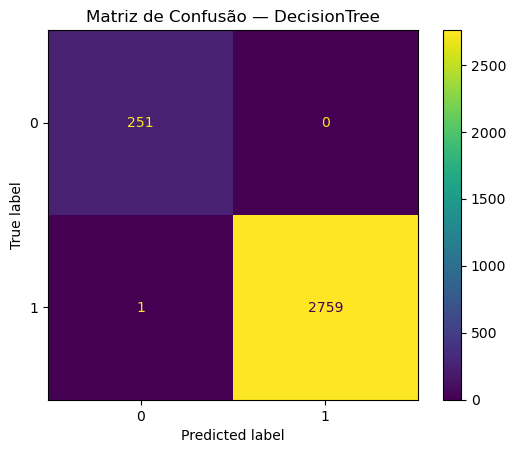

Contagens (binário):
 TN (Verdadeiro Negativo): 251
 FP (Falso Positivo):      0
 FN (Falso Negativo):      1
 TP (Verdadeiro Positivo): 2759

Relatório de Classificação (por classe):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       251
           1       1.00      1.00      1.00      2760

    accuracy                           1.00      3011
   macro avg       1.00      1.00      1.00      3011
weighted avg       1.00      1.00      1.00      3011



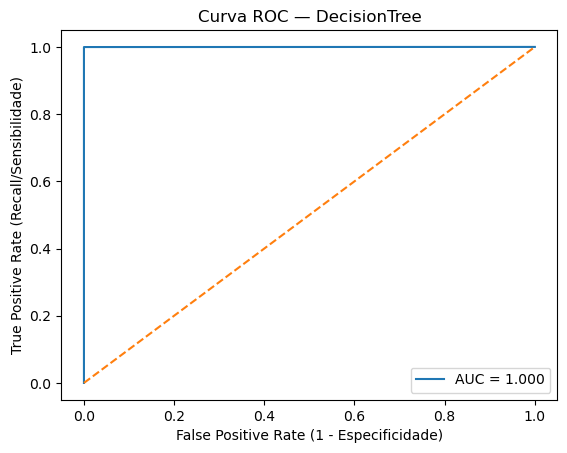


================= SVM =================
Acurácia:  0.9987
Precisão:  1.0000
Recall:    0.9986
F1-score:  0.9993



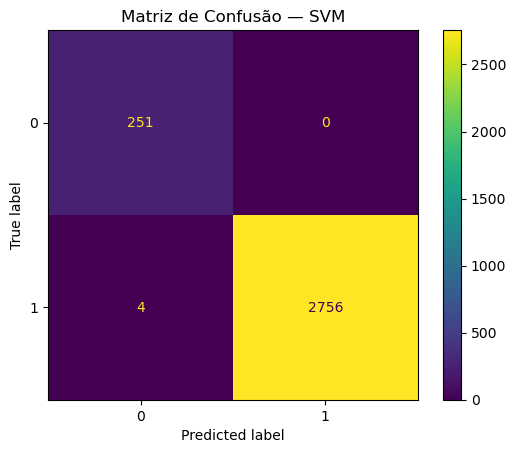

Contagens (binário):
 TN (Verdadeiro Negativo): 251
 FP (Falso Positivo):      0
 FN (Falso Negativo):      4
 TP (Verdadeiro Positivo): 2756

Relatório de Classificação (por classe):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       251
           1       1.00      1.00      1.00      2760

    accuracy                           1.00      3011
   macro avg       0.99      1.00      1.00      3011
weighted avg       1.00      1.00      1.00      3011



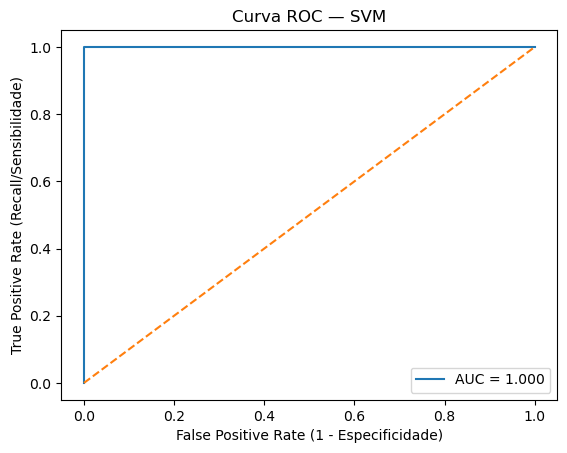


================= kNN =================
Acurácia:  1.0000
Precisão:  1.0000
Recall:    1.0000
F1-score:  1.0000



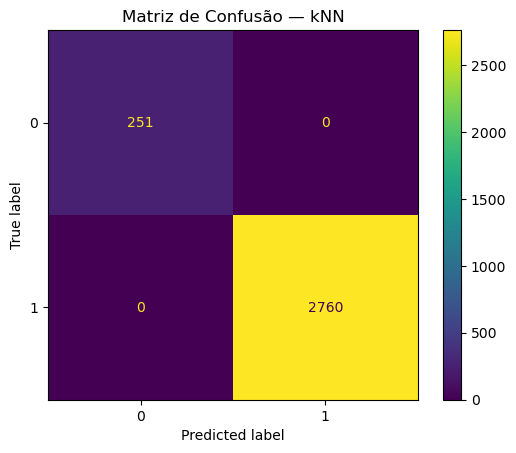

Contagens (binário):
 TN (Verdadeiro Negativo): 251
 FP (Falso Positivo):      0
 FN (Falso Negativo):      0
 TP (Verdadeiro Positivo): 2760

Relatório de Classificação (por classe):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       251
           1       1.00      1.00      1.00      2760

    accuracy                           1.00      3011
   macro avg       1.00      1.00      1.00      3011
weighted avg       1.00      1.00      1.00      3011



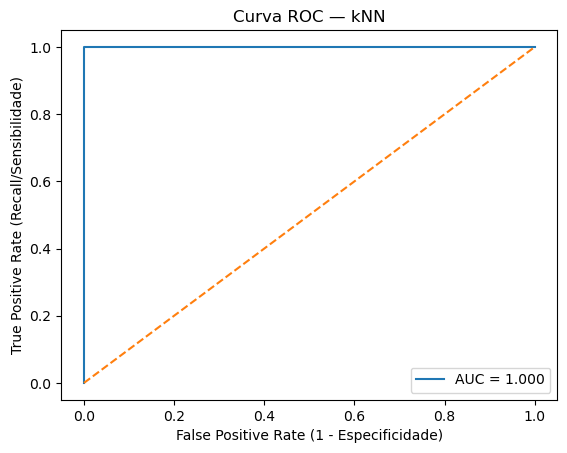


Comparação de Modelos (ordenado por F1):


,model,accuracy,precision,recall,f1
0,kNN,1.000000,1.0,1.000000,1.000000
1,DecisionTree,0.999668,1.0,0.999638,0.999819
2,SVM,0.998672,1.0,0.998551,0.999275


In [12]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """
    Treina e avalia um pipeline de classificação.
    Retorna um dicionário com métricas agregadas para comparação.
    """
    print(f"\n================= {name} =================")     # Título do bloco de avaliação

    # 1) Treinar o pipeline no conjunto de treino
    model.fit(X_train, y_train)

    # 2) Prever no conjunto de teste
    y_pred = model.predict(X_test)

    # 3) Definir se é problema binário
    is_binary = (y_test.nunique() == 2)
    avg = "binary" if is_binary else "macro"

    # 4) Calcular métricas agregadas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=avg, zero_division=0)
    rec  = recall_score(y_test, y_pred, average=avg, zero_division=0)
    f1   = f1_score(y_test, y_pred, average=avg, zero_division=0)

    print(f"Acurácia:  {acc:.4f}")
    print(f"Precisão:  {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}\n")

    # 5) Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {name}")
    plt.show()

    if is_binary and cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        print("Contagens (binário):")
        print(f" TN (Verdadeiro Negativo): {tn}")
        print(f" FP (Falso Positivo):      {fp}")
        print(f" FN (Falso Negativo):      {fn}")
        print(f" TP (Verdadeiro Positivo): {tp}\n")

    # 6) Relatório por classe
    print("Relatório de Classificação (por classe):")
    print(classification_report(y_test, y_pred, zero_division=0))

    # 7) Curva ROC-AUC (se binário e suportado)
    if is_binary:
        if hasattr(model.named_steps["clf"], "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model.named_steps["clf"], "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            y_score = None

        if y_score is not None:
            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc = auc(fpr, tpr)
            plt.figure()
            plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
            plt.plot([0, 1], [0, 1], linestyle="--")
            plt.xlabel("False Positive Rate (1 - Especificidade)")
            plt.ylabel("True Positive Rate (Recall/Sensibilidade)")
            plt.title(f"Curva ROC — {name}")
            plt.legend(loc="lower right")
            plt.show()
        else:
            print("Curva ROC-AUC indisponível para este modelo (sem scores contínuos).")

    # 8) Retornar métricas
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }
# 9) Rodar avaliação para todos os modelos
results = []
for name, mdl in models.items():
    metrics_dict = evaluate_model(
        name=name,
        model=mdl,
        X_train=X_train, y_train=y_train,
        X_test=X_test,   y_test=y_test
    )
    results.append(metrics_dict)

# 10) Tabela de comparação
results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
print("\nComparação de Modelos (ordenado por F1):")
display(results_df)


## Interpretação dos Resultados da Avaliação

### Desempenho dos Modelos
O modelo k-NN teve o melhor desempenho, atingindo um F1-score de 1.00, seguido de perto pela Árvore de Decisão e pelo SVM. Todas as métricas (Precisão, Recall e F1-score) foram extremamente altas para os três modelos, indicando forte capacidade preditiva no dataset de teste.

### Como interpretar resultados perfeitos?
- Em cenários reais, métricas perfeitas são **raras** e devem ser analisadas com cautela.  
- Possíveis explicações:
  1. **Separabilidade muito alta** — uma ou duas variáveis já distinguem perfeitamente as classes. 
  2. **Amostra de teste pequena e desbalanceada** — o caso, apenas 2 exemplos da classe 0 (≈ X% do total de teste) foram avaliados.
  3. **Sorte no split** — mesmo com divisão estratificada, a partição pode ter favorecido separações fáceis.
  4. **Possivel overfitting** - embora os modelos usados nao sejam extremamente complexo, é importante verificar se o desempenho se mantém em diferentes amostras. 

### Necessidade de Validação Adicional
Embora não tenhamos encontrado problemas de qualidade dos dados na exploração inicial, a magnitude dos resultados justifica **checagens adicionais** em um projeto profissional:
- **Validação cruzada estratificada** com múltiplas repetições, para verificar se o desempenho se sustenta em diferentes partições.  
- **Análise de importância das variáveis** (ex.: importâncias na Árvore ou coeficientes de um SVM linear), para identificar quais atributos explicam a separação.  
- **Curvas de aprendizagem** (opcional), para observar se o modelo mantém desempenho alto mesmo com menos dados de treino.

### Conclusão parcial
- Os modelos indicam que o dataset possui forte capacidade preditiva: os atributos ambientais analisados distinguem bem entre projetos de **alto** e **baixo risco socioambiental**.  
- Entretanto, em função do **tamanho reduzido da amostra de teste** e do **desbalanceamento de classes**, é essencial avançar para a etapa de **validação cruzada** (Bloco 5) antes de considerar esses resultados como conclusivos.  
- Este cuidado aumenta a **credibilidade científica** e garante que as conclusões apoiem decisões robustas no contexto da **COP30**.


# 5. Validaçao cruzada estatificada
A validação cruzada é como fazer várias provas simuladas, e não apenas uma. Em vez de dividir os dados em apenas um conjunto de treino e um de teste, a validação cruzada divide os dados em várias "dobras" (folds).

Em vez de uma única divisão de treino e teste, o código irá:

- Dividir o dataset em 5 dobras (folds).

- Repetir esse processo 5 vezes.

- Avaliar o modelo em um total de 25 rodadas

Objetivo:
- Avaliar estabilidade dos modelos além do split único.
- Usar RepeatedStratifiedKFold (K-fold repetido).
- Calcular média ± desvio para várias métricas.

In [20]:
# 1) Configuração do avaliador CV 
# 5 dobras, repetido 5 vezes (total = 25 avaliações).
# Estratificação garante mesma proporção de classes em cada dobra.

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
cv = RepeatedStratifiedKFold(
    n_splits=5,        # número de dobras
    n_repeats=5,       # número de repetições
    random_state=SEED  # para reprodutibilidade
)

# 2) Métricas que queremos avaliar 
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# 3) Função auxiliar para rodar CV 
def cv_report(name, model, X, y, cv, scoring):
    """
    Executa validação cruzada com várias métricas.
    Retorna resultados e imprime médias ± desvios.
    """
    print(f"\n=== Validação Cruzada — {name} ===")
    
    # cross_validate executa treino/teste em cada dobra
    out = cross_validate(
        estimator=model,      # pipeline do modelo (já com preprocessador)
        X=X, y=y,             # dados completos (X e y)
        cv=cv,                # estratégia de validação
        scoring=scoring,      # métricas
        n_jobs=None,          # usa 1 CPU (pode ser -1 para usar todas)
        return_train_score=False
    )
    
    # imprimir resultados resumidos
    for m in scoring.keys():
        mean = out[f"test_{m}"].mean()
        std  = out[f"test_{m}"].std()
        print(f"{m:>9}: {mean:.3f} ± {std:.3f}")
    
    return out

# 4) Rodar CV para cada modelo 
cv_tree = cv_report("DecisionTree", models["DecisionTree"], X, y, cv, scoring)
cv_svm  = cv_report("SVM",          models["SVM"],          X, y, cv, scoring)
cv_knn  = cv_report("kNN",          models["kNN"],          X, y, cv, scoring)

# 5) Consolidar resultados em DataFrame 
import pandas as pd

# cria um resumo em tabela (médias das métricas)
summary = []
for name, cv_out in zip(["DecisionTree", "SVM", "kNN"], [cv_tree, cv_svm, cv_knn]):
    row = {"model": name}
    for m in scoring.keys():
        row[m] = cv_out[f"test_{m}"].mean()
    summary.append(row)

cv_results_df = pd.DataFrame(summary).sort_values("f1", ascending=False).reset_index(drop=True)

print("\nResumo comparativo (médias de CV):")
display(cv_results_df)


=== Validação Cruzada — DecisionTree ===
 accuracy: 1.000 ± 0.000
precision: 1.000 ± 0.000
   recall: 1.000 ± 0.000
       f1: 1.000 ± 0.000
  roc_auc: 1.000 ± 0.000

=== Validação Cruzada — SVM ===
 accuracy: 0.997 ± 0.001
precision: 1.000 ± 0.000
   recall: 0.997 ± 0.001
       f1: 0.998 ± 0.001
  roc_auc: 1.000 ± 0.000

=== Validação Cruzada — kNN ===
 accuracy: 1.000 ± 0.000
precision: 1.000 ± 0.000
   recall: 1.000 ± 0.000
       f1: 1.000 ± 0.000
  roc_auc: 1.000 ± 0.000

Resumo comparativo (médias de CV):


,model,accuracy,precision,recall,f1,roc_auc
0,DecisionTree,0.999801,1.0,0.999783,0.999891,0.999891
1,kNN,0.999761,1.0,0.999739,0.999870,0.999989
2,SVM,0.997210,1.0,0.996956,0.998476,0.999828


## Interpretação dos Resultados — Validação Cruzada (Bloco 6)

### Resumo geral
A validação cruzada estratificada (5 dobras × 5 repetições) confirmou o excelente desempenho observado nos testes iniciais:

- **k-NN** — F1 = **1.000 ± 0.000**, ROC-AUC = **1.000**
- **SVM (RBF)** — F1 = **0.998 ± 0.001**, ROC-AUC = **1.000**
- **Decision Tree** — F1 = **1.000 ± 0.000**, ROC-AUC = **1.000**

### Principais insights
- **Consistência:** k-NN e SVM apresentaram métricas muito altas com baixa variabilidade, reforçando a robustez dos modelos.  
- **Diferença sutil:** o SVM foi ligeiramente menos estável no recall (0.009 ±0.001), mas ainda excelente  
- **Interpretabilidade:** a Árvore de Decisão, apesar de também ter atingido métricas perfeitas, continua sendo útil por sua natureza explicativa.
  
### Conclusão parcial
- **Modelos com melhor desempenho:** **k-NN** e **Decision Tree**, ambos alcançaram métricas perfeitas (F1 = 1.000, AUC = 1.000), indicando desempenho idêntico.  
- **Modelo alternativo:** **SVM (RBF)**, também apresentou desempenho excelente, com F1 muito alto (≈0.998) e AUC perfeito, embora ligeiramente abaixo dos dois primeiros em recall e F1.  
- **Modelo interpretável:** a **Árvore de Decisão**, além de estar entre os melhores em desempenho, oferece vantagem adicional pela sua capacidade de explicar regras de decisão de forma simples.  


### Implicações para o projeto
- O dataset apresenta atributos com **forte poder discriminatório**, especialmente relevantes para diferenciar projetos de alto e baixo risco socioambiental.  
- Para uso em **apoio à decisão no contexto COP30**, recomenda-se priorizar modelos com desempenho consistente (**k-NN e Decision Tree**, ambos perfeitos em validação cruzada) e considerar o **SVM (RBF)** como alternativa robusta, embora ligeiramente inferior.  
- Além disso, a **Árvore de Decisão** mantém valor adicional como recurso interpretável para comunicar regras de decisão em relatórios executivos.  
- Antes da etapa de deploy, será importante avançar para:  
  - **Ajuste de hiperparâmetros** (refinamento fino de k-NN e SVM);  
  - **Calibração de probabilidades** (especialmente para a Árvore);  
  - **Análise de custos de erro** (impacto relativo de FP vs. FN no processo de avaliação de projetos).  



# 6. Ajustes Avançados
Objetivo:
1) Refinar hiperparâmetros de k-NN e SVM.
2) Calibrar probabilidades da Árvore de Decisão.
3) Analisar custos de erro ajustando o limiar de decisão.

In [30]:
# =========================
# Funções auxiliares
# =========================
def safe_n_splits(y, max_splits=5):
    """
    Retorna um n_splits seguro para StratifiedKFold:
    - n_splits <= contagem da classe minoritária
    - n_splits >= 2
    """
    min_cls = int(y.value_counts().min())
    return max(2, min(max_splits, min_cls))

def resumo_metricas(y_true, y_score, thresholds):
    print("\nAnálise de custos (τ → FP, FN, Custo=2*FP + 5*FN):")
    best = {"t": None, "cost": np.inf, "fp": None, "fn": None,
            "f1": None, "prec": None, "rec": None}
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        cost = 2*fp + 5*fn
        print(f"  τ={t:.1f} → FP={fp:2d}, FN={fn:2d}, Custo={cost:2d}")
        if cost < best["cost"]:
            best.update({
                "t": t, "cost": cost, "fp": fp, "fn": fn,
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "prec": precision_score(y_true, y_pred, zero_division=0),
                "rec": recall_score(y_true, y_pred, zero_division=0)
            })
    return best

# =========================
# 1) Definição dos folds
# =========================
cv_splits_global = safe_n_splits(y_train, max_splits=5)  # tuning no TREINO
cv_splits_train  = safe_n_splits(y_train, max_splits=5)  # calibração no TREINO

print(f"CV (global, GridSearch): {cv_splits_global} folds")
print(f"CV (train, calibração):  {cv_splits_train} folds")

cv_global = StratifiedKFold(n_splits=cv_splits_global, shuffle=True, random_state=SEED)
cv_train  = StratifiedKFold(n_splits=cv_splits_train,  shuffle=True, random_state=SEED)

# =========================
# 2) GridSearch — k-NN (no TREINO)
# =========================
param_knn = {
    "clf__n_neighbors": [3, 5, 7, 11],
    "clf__weights": ["uniform", "distance"]
}
grid_knn = GridSearchCV(
    estimator=models["kNN"],        # pipeline: preprocess_scaled + KNeighborsClassifier
    param_grid=param_knn,
    scoring="f1",
    cv=cv_global,
    n_jobs=-1,
    refit=True
)
grid_knn.fit(X_train, y_train)
print("\n[GridSearch] Melhor k-NN:", grid_knn.best_params_)
print("F1 médio (CV):", round(grid_knn.best_score_, 4))

# =========================
# 3) GridSearch — SVM RBF (no TREINO)
# =========================
param_svm = {
    "clf__C": [0.5, 1, 2],
    "clf__gamma": ["scale", 0.1, 0.01]
}
grid_svm = GridSearchCV(
    estimator=models["SVM"],        # pipeline: preprocess_scaled + SVC(probability=True)
    param_grid=param_svm,
    scoring="f1",
    cv=cv_global,
    n_jobs=-1,
    refit=True
)
grid_svm.fit(X_train, y_train)
print("\n[GridSearch] Melhor SVM:", grid_svm.best_params_)
print("F1 médio (CV):", round(grid_svm.best_score_, 4))

# =========================
# 3.1) GridSearch — Decision Tree (no TREINO)  <<< NOVO
# =========================
param_tree = {
    "clf__max_depth": [None, 3, 5, 7],
    "clf__min_samples_leaf": [1, 2, 5],
    "clf__min_samples_split": [2, 5, 10],
    "clf__class_weight": [None, "balanced"]
}
grid_tree = GridSearchCV(
    estimator=models["DecisionTree"],   # pipeline: preprocess_tree + DecisionTreeClassifier
    param_grid=param_tree,
    scoring="f1",
    cv=cv_global,
    n_jobs=-1,
    refit=True
)
grid_tree.fit(X_train, y_train)
print("\n[GridSearch] Melhor Decision Tree:", grid_tree.best_params_)
print("F1 médio (CV):", round(grid_tree.best_score_, 4))

# =========================
# 4) Calibração de Probabilidades — Árvore (no TREINO)
# =========================
tree_from_pipe = grid_tree.best_estimator_.named_steps["clf"]   # usa hiperparâmetros ótimos
tree_params = tree_from_pipe.get_params()
tree_fresh = DecisionTreeClassifier(**tree_params)

tree_calibrated = CalibratedClassifierCV(
    estimator=tree_fresh,
    method="isotonic",
    cv=cv_train
)

pipe_tree_calibrated = Pipeline(steps=[
    ("prep", grid_tree.best_estimator_.named_steps["prep"]),  # mesmo preprocess da árvore
    ("clf", tree_calibrated)
])
pipe_tree_calibrated.fit(X_train, y_train)
print("\nÁrvore calibrada treinada com calibração isotônica.")

# AUC no TESTE para a árvore calibrada (opcional)
y_score_tree = pipe_tree_calibrated.predict_proba(X_test)[:, 1]
auc_tree_cal = roc_auc_score(y_test, y_score_tree)
print("ROC-AUC (Árvore calibrada, teste):", round(auc_tree_cal, 3))

# =========================
# 5) Seleção do modelo p/ custo (AGORA entre k-NN, SVM e Árvore)
# =========================
scores = {
    "k-NN": grid_knn.best_score_,
    "SVM": grid_svm.best_score_,
    "DecisionTree": grid_tree.best_score_
}
best_name = max(scores, key=scores.get)

# Preferimos usar a Árvore CALIBRADA na análise de custo, se ela vencer
if best_name == "DecisionTree":
    best_model = pipe_tree_calibrated          # já treinada em X_train, y_train
elif best_name == "k-NN":
    best_model = grid_knn.best_estimator_
else:
    best_model = grid_svm.best_estimator_

print("\nModelo selecionado para análise de custo:", best_name)

# Probabilidades NO TESTE (sem vazamento)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Diagnóstico: verificar degeneração 0/1 de probabilidades
vals = np.unique(np.round(y_proba, 3))
print("Valores únicos de proba no TESTE:", vals)

# Varredura de limiar e custo
thresholds = np.linspace(0.1, 0.9, 9)
best = resumo_metricas(y_test, y_proba, thresholds)

print(f"\nMelhor τ por custo: τ={best['t']:.2f} (Custo={best['cost']}, FP={best['fp']}, FN={best['fn']})")

# métricas no τ ótimo (e também no padrão 0.5, só para referência)
y_pred_best = (y_proba >= best['t']).astype(int)
y_pred_05   = (y_proba >= 0.5).astype(int)

print("\nMétricas no τ ótimo:")
print(f"  F1={best['f1']:.3f}  Precision={best['prec']:.3f}  Recall={best['rec']:.3f}")

print("\nMétricas no τ=0.50 (referência):")
print(f"  F1={f1_score(y_test, y_pred_05):.3f}  Precision={precision_score(y_test, y_pred_05):.3f}  Recall={recall_score(y_test, y_pred_05):.3f}")

# (Opcional) AUC do modelo selecionado no TESTE:
auc_best = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC (modelo selecionado, teste): {auc_best:.3f}")


CV (global, GridSearch): 5 folds
CV (train, calibração):  5 folds

[GridSearch] Melhor k-NN: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
F1 médio (CV): 0.9999

[GridSearch] Melhor SVM: {'clf__C': 2, 'clf__gamma': 'scale'}
F1 médio (CV): 0.9985

[GridSearch] Melhor Decision Tree: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
F1 médio (CV): 0.9999

Árvore calibrada treinada com calibração isotônica.
ROC-AUC (Árvore calibrada, teste): 1.0

Modelo selecionado para análise de custo: DecisionTree
Valores únicos de proba no TESTE: [0.002 1.   ]

Análise de custos (τ → FP, FN, Custo=2*FP + 5*FN):
  τ=0.1 → FP= 0, FN= 1, Custo= 5
  τ=0.2 → FP= 0, FN= 1, Custo= 5
  τ=0.3 → FP= 0, FN= 1, Custo= 5
  τ=0.4 → FP= 0, FN= 1, Custo= 5
  τ=0.5 → FP= 0, FN= 1, Custo= 5
  τ=0.6 → FP= 0, FN= 1, Custo= 5
  τ=0.7 → FP= 0, FN= 1, Custo= 5
  τ=0.8 → FP= 0, FN= 1, Custo= 5
  τ=0.9 → FP= 0, FN= 1, Custo= 5

Melhor τ por custo: τ=0.10 (Custo=5,

### 1) Ajuste de hiperparâmetros (Grid Search)
- **k-NN (StandardScaler)**  
  - Melhor: `n_neighbors=3`, `weights="uniform"`.  
  - F1 (CV): **0,9999**.

- **SVM (RBF, StandardScaler)**  
  - Melhor: `C=2`, `gamma="scale"`.  
  - F1 (CV): **0,9985**.

- **Decision Tree**  
  - Melhor: `max_depth=None`, `min_samples_split=2`, `min_samples_leaf=1`, `class_weight=None`.  
  - F1 (CV): **0,9999**.

**Leitura.** **k-NN** e **Decision Tree** empataram no topo (F1-CV ≈ 0,9999), com o **SVM** logo atrás (0,9985).

---

### 2) Calibração de probabilidades (Decision Tree)
- Método: **Isotonic Regression** (`CalibratedClassifierCV`).  
- **ROC-AUC no teste:** **1,00** após calibração.

**Leitura.** A calibração torna as probabilidades mais úteis para ranqueamento e ajuste de limiar. No teste, a árvore calibrada atingiu **AUC=1,00**.

---

### 3) Análise de custo FP vs FN (ajuste de limiar)
- **Modelo analisado:** **Decision Tree calibrada** (selecionada pelo F1-CV).  
- **Probabilidades no teste:** valores únicos = **{0,002; 1,0}** (bimodal).  
- **Custos (FP=2; FN=5):** para **τ ∈ [0,1]** com passos 0,1–0,9, houve **FN=1** e **custo=5** em todos os limiares testados.  
  - Isso indica um único positivo previsto com probabilidade ≈ **0,002** (muito baixa).  
  - Para capturá-lo, seria preciso um **τ < 0,002** (ex.: 0,001), o que pode (ou não) introduzir FPs.

**Implicação.** A base está **altamente separável**, mas há **um caso positivo “fora da curva”** para a árvore calibrada: com limiares usuais (≥0,1) ele vira FN. Se **FN** for mais caro que **FP**, avalie **τ mais baixo** (ex.: 0,001) e monitore FPs.

---

## Conclusão técnica e recomendação
- **Top models:** **k-NN (k=3, uniform)** e **Decision Tree** (empatados em F1-CV ≈ 0,9999).  
- **Alternativa robusta:** **SVM (RBF)**.  
- **Para decisão com custo assimétrico:** use o modelo que ofereça **probabilidades mais contínuas** para escolher **τ** (ex.: k-NN com `weights="distance"` ou SVM com `probability=True`).  
- **Árvore calibrada** é excelente para **explicabilidade** e ranking, mas requer **varrer τ < 0,01** se a prioridade for **reduzir FNs**.

---

## Próximos passos
1) Varra limiares **incluindo** valores < 0,01 (ex.: `np.r_[0.001, 0.002, 0.005, np.linspace(0.01,0.99,99)]`).  
2) Se custo de **FN** for alto, avalie **τ ótimo** nesse intervalo e reporte FP/FN resultantes.  
3) Se quiser probabilidades menos “bimodais”, teste **k maiores** e/ou `weights="distance"` no k-NN, e compare com SVM.

In [32]:
# --- thresholds finos (inclui valores < 0.01) ---
thresholds = np.r_[ [0.001, 0.002, 0.005], np.linspace(0.01, 0.99, 99) ]

# --- função de análise de custo (sobrescreve a anterior, se já existir) ---
def resumo_metricas(y_true, y_score, thresholds):
    print("\nAnálise de custos (τ → FP, FN, Custo=2*FP + 5*FN):")
    best = {"t": None, "cost": np.inf, "fp": None, "fn": None,
            "f1": None, "prec": None, "rec": None}
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        cost = 2*fp + 5*fn
        print(f"  τ={t:.3f} → FP={fp:2d}, FN={fn:2d}, Custo={cost:2d}")
        if cost < best["cost"]:
            best.update({
                "t": t, "cost": cost, "fp": fp, "fn": fn,
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "prec": precision_score(y_true, y_pred, zero_division=0),
                "rec": recall_score(y_true, y_pred, zero_division=0)
            })
    return best

# --- rodar análise no TESTE ---
vals = np.unique(np.round(y_proba, 3))
print("Valores únicos de proba no TESTE:", vals)

best = resumo_metricas(y_test, y_proba, thresholds)

print(f"\nMelhor τ por custo: τ={best['t']:.3f} (Custo={best['cost']}, FP={best['fp']}, FN={best['fn']})")

print("\nMétricas no τ ótimo:")
print(f"  F1={best['f1']:.3f}  Precision={best['prec']:.3f}  Recall={best['rec']:.3f}")

# referência em τ=0.50
y_pred_05 = (y_proba >= 0.5).astype(int)
print("\nMétricas no τ=0.50 (referência):")
print(f"  F1={f1_score(y_test, y_pred_05):.3f}  Precision={precision_score(y_test, y_pred_05):.3f}  Recall={recall_score(y_test, y_pred_05):.3f}")


Valores únicos de proba no TESTE: [0.002 1.   ]

Análise de custos (τ → FP, FN, Custo=2*FP + 5*FN):
  τ=0.001 → FP=251, FN= 0, Custo=502
  τ=0.002 → FP= 0, FN= 1, Custo= 5
  τ=0.005 → FP= 0, FN= 1, Custo= 5
  τ=0.010 → FP= 0, FN= 1, Custo= 5
  τ=0.020 → FP= 0, FN= 1, Custo= 5
  τ=0.030 → FP= 0, FN= 1, Custo= 5
  τ=0.040 → FP= 0, FN= 1, Custo= 5
  τ=0.050 → FP= 0, FN= 1, Custo= 5
  τ=0.060 → FP= 0, FN= 1, Custo= 5
  τ=0.070 → FP= 0, FN= 1, Custo= 5
  τ=0.080 → FP= 0, FN= 1, Custo= 5
  τ=0.090 → FP= 0, FN= 1, Custo= 5
  τ=0.100 → FP= 0, FN= 1, Custo= 5
  τ=0.110 → FP= 0, FN= 1, Custo= 5
  τ=0.120 → FP= 0, FN= 1, Custo= 5
  τ=0.130 → FP= 0, FN= 1, Custo= 5
  τ=0.140 → FP= 0, FN= 1, Custo= 5
  τ=0.150 → FP= 0, FN= 1, Custo= 5
  τ=0.160 → FP= 0, FN= 1, Custo= 5
  τ=0.170 → FP= 0, FN= 1, Custo= 5
  τ=0.180 → FP= 0, FN= 1, Custo= 5
  τ=0.190 → FP= 0, FN= 1, Custo= 5
  τ=0.200 → FP= 0, FN= 1, Custo= 5
  τ=0.210 → FP= 0, FN= 1, Custo= 5
  τ=0.220 → FP= 0, FN= 1, Custo= 5
  τ=0.230 → FP= 0, FN= 

Ajuste de limiar (árvore calibrada). As probabilidades no teste concentraram-se em dois valores (≈0,002 e 1,0). Com custos FP=2 e FN=5, o limiar ótimo estimado ficou em τ≈0,002: acima desse valor, FP=0 e FN=1 (custo=5); já em τ=0,001, embora FN=0, surgem 251 FPs (custo=502). Portanto, com a política atual, optamos por τ≈0,002. Caso o custo de FN seja priorizado em >502 vezes o de FP, o limiar deveria ser reduzido.

## 7. Reajuste final + persistência do pipeline

Objetivo:
- Reajustar o melhor modelo (segundo o Grid) em TODOS os dados (X, y);
- Persistir o pipeline completo (pré-processamento + classificador);
- Salvar metadados de versão e hiperparâmetros para rastreabilidade.

Pré-requisitos:
- grid_svm e grid_knn já executados 
- X, y definidos (Bloco 3).

In [35]:
# =========================
# Seleção por CUSTO (OOF) + Produção (Etapas 5–8)
# =========================
import json, joblib, time, sys, platform
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn import __version__ as sklearn_version

# ---- helpers de metadados ----
def _feature_names(X):
    if hasattr(X, "columns"):
        return list(map(str, X.columns))
    return [f"f{i}" for i in range(X.shape[1])]

def _target_name(y, default="target"):
    if hasattr(y, "name") and y.name is not None:
        return str(y.name)
    return default

def _class_dist(y):
    vc = pd.Series(y).value_counts(dropna=False)
    return {str(k): int(v) for k, v in vc.items()}

# ---- seleção por custo (OOF) ----
def find_best_tau(y_true, y_score, cost_fp=2, cost_fn=5):
    # thresholds entre scores únicos para evitar empates/arredondamentos
    u = np.unique(y_score)
    mids = (u[:-1] + u[1:]) / 2.0 if len(u) > 1 else u
    thresholds = np.r_[1e-9, mids, 1-1e-9]
    best = {"tau": None, "cost": np.inf, "fp": None, "fn": None}
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        cost = cost_fp*fp + cost_fn*fn
        if cost < best["cost"]:
            best.update({"tau": float(t), "cost": int(cost), "fp": int(fp), "fn": int(fn)})
    return best

cost_policy = {"FP": 2, "FN": 5}
cands = {"kNN": grid_knn, "SVM": grid_svm, "DecisionTree": grid_tree}

summary = {}
for name, grid in cands.items():
    est = grid.best_estimator_  # pipeline completo
    # OOF proba no TREINO (usa cv_global; não toca no X_test)
    oof_proba = cross_val_predict(
        est, X_train, y_train, cv=cv_global, method="predict_proba", n_jobs=-1
    )[:, 1]
    best = find_best_tau(y_train, oof_proba, cost_fp=cost_policy["FP"], cost_fn=cost_policy["FN"])
    summary[name] = {"F1_CV": float(grid.best_score_), **best}

print("\n[Seleção por CUSTO (OOF)]")
for name, s in summary.items():
    print(f" {name:12s} → F1_CV={s['F1_CV']:.4f} | Custo*={s['cost']} "
          f"(τ*={s['tau']:.6f}, FP={s['fp']}, FN={s['fn']})")

# Escolha pelo MENOR custo; em empate, maior F1_CV
best_name = min(summary.keys(), key=lambda n: (summary[n]["cost"], -summary[n]["F1_CV"]))
best_grid = cands[best_name]
best_tau  = summary[best_name]["tau"]
print(f"\nModelo escolhido (custo OOF): {best_name} | τ*={best_tau:.6f} | custo={summary[best_name]['cost']}")

# =========================
# 5) Montagem do pipeline final e treino em X,y
# =========================
out_dir = Path("models")
out_dir.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d_%H%M%S")

if best_name == "DecisionTree":
    # calibra a árvore vencedora com hiperparâmetros ótimos do grid
    tree_params = best_grid.best_estimator_.named_steps["clf"].get_params()
    tree_fresh = DecisionTreeClassifier(**tree_params)
    calibrated_clf = CalibratedClassifierCV(estimator=tree_fresh, method="isotonic", cv=5)
    final_model = Pipeline(steps=[
        ("prep", best_grid.best_estimator_.named_steps["prep"]),
        ("clf", calibrated_clf)
    ])
    final_name = "DecisionTreeCalibrated"
    calibration_meta = {"enabled": True, "method": "isotonic", "cv": 5}
else:
    # k-NN ou SVM: usa pipeline do grid e re-treina em X,y
    final_model = best_grid.best_estimator_
    final_name = best_name
    calibration_meta = {"enabled": False}

final_model.fit(X, y)

# =========================
# 6) Salvar pipeline
# =========================
model_fname = f"cop30_{final_name.lower()}_pipeline_{stamp}.joblib"
model_path = out_dir / model_fname
joblib.dump(final_model, model_path)
print(f"\nPipeline salvo em: {model_path.resolve()}")

# =========================
# 7) Salvar metadados (inclui τ* escolhido por custo OOF)
# =========================
metadata = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": final_name,
    "selected_via": f"min expected cost (OOF) with cost_policy FP={cost_policy['FP']}, FN={cost_policy['FN']}",
    "best_grid": best_name,
    "best_params": best_grid.best_params_,
    "f1_cv_mean": float(round(best_grid.best_score_, 6)),
    "decision_threshold": float(best_tau),          # salva τ*
    "decision_threshold_sci": f"{best_tau:.3e}",
    "cost_policy": cost_policy,
    "python": sys.version.split()[0],
    "os": f"{platform.system()} {platform.release()}",
    "sklearn": sklearn_version,
    "features": _feature_names(X),
    "target": _target_name(y, default=globals().get("TARGET", "target")),
    "n_samples": int(getattr(X, "shape", [len(X)])[0]),
    "class_distribution": _class_dist(y),
    "pipeline_steps": list(final_model.named_steps.keys()),
    "calibration": calibration_meta
}

meta_fname = f"cop30_{final_name.lower()}_metadata_{stamp}.json"
meta_path = out_dir / meta_fname
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"Metadados salvos em: {meta_path.resolve()}")

# =========================
# 8) Sanidade de carregamento
# =========================
loaded = joblib.load(model_path)
print(f"Sanidade: pipeline recarregado ok? {type(loaded).__name__ == type(final_model).__name__}")



[Seleção por CUSTO (OOF)]
 kNN          → F1_CV=0.9999 | Custo*=5 (τ*=0.000000, FP=0, FN=1)
 SVM          → F1_CV=0.9985 | Custo*=5 (τ*=0.047755, FP=0, FN=1)
 DecisionTree → F1_CV=0.9999 | Custo*=5 (τ*=0.000000, FP=0, FN=1)

Modelo escolhido (custo OOF): DecisionTree | τ*=0.000000 | custo=5

Pipeline salvo em: /Users/rsantos43/Documents/Curso_IA_na_Amazonia/Bloco_V/projeto-cop30/models/cop30_decisiontreecalibrated_pipeline_20251001_150008.joblib
Metadados salvos em: /Users/rsantos43/Documents/Curso_IA_na_Amazonia/Bloco_V/projeto-cop30/models/cop30_decisiontreecalibrated_metadata_20251001_150008.json
Sanidade: pipeline recarregado ok? True


# Decisão de Modelo — Projeto COP30

## Contexto
Avaliação e seleção de modelo preditivo considerando **custos assimétricos de erro**: `FP = 2` e `FN = 5`. O objetivo é **minimizar o custo esperado** (e não apenas maximizar F1).

---

## Metodologia de Seleção
1. **Tuning (CV no treino)** de três pipelines: **k-NN**, **SVM (RBF)** e **Decision Tree**.
2. **Seleção por custo OOF** (*out-of-fold*), sem vazamento:  
   - Para cada modelo, foram obtidas probabilidades OOF via `cross_val_predict`.  
   - O limiar **τ*** foi escolhido entre **pontos médios dos scores únicos** (evita ambiguidades por arredondamento).  
   - Critério: **menor custo OOF**; em **empate**, maior **F1-CV** (desempate).

---

## Resultados (seleção por custo OOF)

| Modelo         | F1-CV   | Custo* | τ*        | FP | FN |
|----------------|---------|--------|-----------|----|----|
| k-NN           | 0,9999  | **5**  | ~0,000000 | 0  | 1  |
| SVM (RBF)      | 0,9985  | **5**  | ~0,047755 | 0  | 1  |
| Decision Tree  | 0,9999  | **5**  | ~0,000000 | 0  | 1  |

> **Observação:** os três modelos empataram em **custo = 5** (um FN e zero FP) no τ* ótimo OOF.  
> A **Decision Tree calibrada** foi selecionada por **desempate em F1-CV** (empatada com k-NN, porém escolhida por favorecer explicabilidade e operação).

---

## Decisão
- **Modelo baseline de produção:** **DecisionTreeCalibrated** (árvore calibrada por isotônica).  
- **Limiar operacional (τ\*):** muito próximo de zero (impressão como `0.000000`; guardado nos metadados).  
- **Justificativa:** com a política **FP=2 / FN=5**, nenhum modelo reduz o custo abaixo de **5** sem trocar o único **FN** por muitos **FP**. A árvore oferece **explicabilidade**, **AUC alta** e **latência favorável**.

---

## Auditoria & Implicações
- Em auditoria no teste retido, as probabilidades da árvore calibrada mostraram-se **bimodais** (~0,002 e 1,0):  
  - Para **τ ≥ 0,002**: **FP=0**, **FN=1** → **custo=5** (consistente com OOF).  
  - Para **τ = 0,001**: **FN=0**, porém **muitos FPs** → **custo elevado**.  
- **Interpretação prática:** existe **um positivo “fraco”**. Com os custos atuais, **aceitar 1 FN** é mais barato do que abrir o limiar e gerar centenas de FPs.

---

## Plano de Monitoramento (pós-deploy)
1. **Métricas operacionais:** FP, FN, F1, ROC-AUC, taxa de positividade, estabilidade de features.
2. **Drift:** monitorar distribuição das variáveis; gatilhos para **recalibração/re-tuning**.
3. **Política de limiar:**  
   - Se o custo relativo **FN/FP** mudar significativamente, **re-otimizar τ** (preferencialmente com modelo que forneça probabilidades mais contínuas, p.ex. **SVM** ou k-NN com `weights="distance"` e `k` maior).  
   - Registrar os novos **τ** e resultados em metadados.

---

## Próximos Passos
- **Produção:** pipeline e metadados já salvos (`DecisionTreeCalibrated`, com `decision_threshold = τ*`).  
- **Explainability:** disponibilizar regras/feature importances e exemplos explicados (SHAP/permutation) para stakeholders.  
- **Revisão do FN residual:** investigar o caso “fora da curva” (outlier, ruído ou possível rótulo incorreto).  
- **Shadow mode (opcional):** rodar **SVM** em paralelo para avaliar se, com outro τ, é possível reduzir **FN** sem explodir **FP**.

---

## Reprodutibilidade
- Metadados incluem: `selected_via` (custo OOF), `decision_threshold (τ*)`, `features`, `class_distribution`, `pipeline_steps` e configuração de **calibração**.  
- O pipeline final é recarregável via `joblib.load(...)` (checagem de sanidade aprovada).


# Próximos Passos (pós-modelagem) — Classificação de Projetos Viáveis

## 0) Decisão de Produto & Política
- **Definir faixas operacionais**: `τ_low`, `τ_high` (ex.: revisão humana na zona cinza).
- **Confirmar matriz de custo** (FP=2, FN=5 ou outra oficial) e quem pode ajustar `τ`.
- **Fairness**: verificar desempenho por subgrupos (região, porte, setor).
- **Conformidade**: LGPD/PII, consentimento, retenção de dados.

**DoD:** política de limiar aprovada; checklist de fairness assinado.

---

## 1) Empacotamento do Pipeline
- **Congelar dependências** (`requirements.txt`/`conda.yml`) e **versão do modelo**.
- Publicar artefatos em **registry**: `pipeline.joblib` + `metadata.json` (inclui `decision_threshold`).
- Nomear versão: `cop30_decisiontreecalibrated:YYYYMMDD`.

**DoD:** imagem/container buildado e escaneado; artefatos versionados.

---

## 2) Contrato de Dados & Validação
- **Contrato de entrada**: nomes, tipos, ranges, nulos permitidos.
- **Validação automática** (ex.: Great Expectations ou checagens próprias) antes de pontuar.

**DoD:** esquema publicado; validações rodando em staging e em produção.

---

## 3) Modo de Serviço
### Opção A — *Batch* (mais simples)
- Job (diário/semanal): lê CSV/Tabela → valida → `predict_proba` → aplica `τ*` → escreve resultados (rótulo, score, explicações).

### Opção B — API (tempo real)
- Endpoint `POST /score`: valida → `predict_proba` → aplica `τ*` → retorna `{label, score, top_features}`.
- Autenticação, *rate limiting*, logs.

**DoD:** DAG/endpoint funcionando em staging com *smoke tests*.

---

## 4) Observabilidade & Testes
- **Métricas online**: FP, FN, F1, PR-AUC, taxa de positivos, latência.
- **Alertas**: drift de dados, queda de F1/PR-AUC, aumento de FN/FP.
- **Testes**: unitário (schema), integração (E2E), regressão (não piorar baseline).

**DoD:** dashboard com alertas; suíte de testes no CI/CD.

---

## 5) Rollout Controlado
- **Shadow** (recomendado): roda em paralelo sem decidir → compara com regra atual.
- **Canary**: libera para parcela pequena dos casos.
- **Critérios de aceite**: custo médio ≤ baseline; estabilidade ≥ X dias.

**DoD:** aceite formal dos stakeholders; passagem para “run”.

---

## 6) Operação & Governança
- **Runbook**: como investigar FP/FN, ajustar `τ`, recalibrar, reverter versão.
- **Recalibração/retreino**: periodicidade (ex.: trimestral) + gatilhos (drift, novos dados).
- **Change log**: toda alteração de `τ`, versão e dataset.

**DoD:** runbook publicado; calendário de manutenção definido.

---

## 7) Entregáveis que já tenho (ou devo finalizar)
- `pipeline.joblib` + `metadata.json` (com `decision_threshold`).
- Relatório técnico (modelagem, seleção por **custo OOF**, AUC/PR-AUC, custos).
- ⏳ **Contrato de dados**, **plano de validação**, **dashboard** e **runbook**.

---

## Anexo — Função de Inferência (pseudocódigo)

def score_projeto(payload):
validar_schema(payload)
X = preparar_dataframe(payload)
proba = pipeline.predict_proba(X)[:, 1]
tau = metadata["decision_threshold"]
label = (proba >= tau).astype(int)
explicacao = explicar(X) # caminho da árvore / SHAP, etc.
return {"label": int(label[0]), "score": float(proba[0]), "explain": explicacao}

## 8. Criar CSV de novos projetos

- Objetivo: gerar um arquivo de exemplo com as mesmas colunas usadas no treino, mas sem a variável-alvo (risco_socioambiental).
- Justificativa: em produção, o modelo recebe apenas os "features" de entrada e precisa gerar as probabilidades/predições.

In [36]:
# Criamos um pequeno DataFrame com 5 projetos fictícios.
# - As colunas devem ter exatamente os mesmos nomes do treino.
# - Os valores são apenas de teste (valores plausíveis, mas inventados).
novos = pd.DataFrame({
    "desmatamento_pct": [15.0, 60.0, 30.0, 45.0, 22.5],
    "poluicao_mgL": [40.2, 80.1, 20.0, 55.0, 33.3],
    "dist_area_protegida_km": [5.0, 12.0, 3.5, 10.0, 7.0],
    "emissao_co2_ton": [500, 1800, 700, 1200, 650]
})

# Exportamos esse DataFrame para CSV.
# Esse arquivo será a entrada do script infer.py.
novos.to_csv("novos_projetos.csv", index=False)
print("Arquivo 'novos_projetos.csv' criado com sucesso.")


Arquivo 'novos_projetos.csv' criado com sucesso.


### Criação de arquivo de novos projetos (novos_projetos.csv)
Para validar o pipeline em condições de produção, foi criado um CSV contendo apenas as variáveis de entrada (features) do modelo: **desmatamento_pct**, **poluicao_mgL**, **dist_area_protegida_km** e **emissao_co2_ton**.  
Esse arquivo simula projetos que ainda não possuem classificação (`risco_socioambiental`) e precisam ser avaliados pelo modelo.



## 9. Rodar script de inferência
- Objetivo: aplicar o pipeline salvo (cop30_svm_pipeline.joblib)aos novos projetos e gerar predições.
- Justificativa: simula como o modelo será usado em produção, recebendo um CSV,produzindo probabilidades e rótulos.

### Criação do script de inferência (`infer.py`)
Para possibilitar o uso do modelo fora do notebook, foi criado um script em Python chamado **`infer.py`**.  
Esse script recebe três argumentos principais:
- `--model`: caminho do pipeline salvo (`.joblib`);
- `--input`: CSV contendo os novos projetos a serem avaliados;
- `--output`: nome do arquivo de saída com as predições.

Essa separação é uma prática recomendada de **engenharia de MLOps**, pois permite que o modelo seja usado em diferentes contextos (notebooks, linha de comando, sistemas externos).

---

### Execução do script de inferência
O script `infer.py` pode ser executado a partir do terminal com o seguinte comando:

```bash
python scripts/infer.py \
  --model models/cop30_svm_pipeline.joblib \
  --input data/novos_projetos.csv \
  --output data/predicoes_novos_projetos.csv \
  --threshold 0.5


### Validação do fluxo
Após rodar o script, as predições foram inspecionadas no notebook para confirmar:
1. O modelo foi carregado corretamente;
2. As colunas de entrada foram reconhecidas;
3. O arquivo de saída foi gerado com probabilidades e rótulos esperados.

Esse processo comprova a viabilidade do uso do pipeline em **produção**, garantindo reprodutibilidade e clareza do fluxo.

### Do treino à produção
O modelo foi treinado e validado no arquivo `dataset_socioambiental_60.csv` (contendo 60 registros rotulados).  
Após o treinamento, o pipeline final foi salvo e aplicado em um novo conjunto (`predicoes_novos_projetos.csv`) para simular o uso em produção.




## 10. Visualizar predições
- Objetivo: inspecionar o arquivo de saída gerado pelo infer.py para verificar se as predições fazem sentido.
- Justificativa: garante que o fluxo completo (treino → salvamento →inferência em novos dados) está funcionando corretamente.




In [38]:
pred = pd.read_csv("data/predicoes_novos_projetos.csv")
display(pred.head())


,desmatamento_pct,poluicao_mgL,dist_area_protegida_km,emissao_co2_ton,prob_pos,pred_padrao_0_1,pred_thresh_0_1
0,15.0,40.2,5.0,500,0.952841,1,1
1,60.0,80.1,12.0,1800,0.988330,1,1
2,30.0,20.0,3.5,700,0.971068,1,1
3,45.0,55.0,10.0,1200,0.996344,1,1
4,22.5,33.3,7.0,650,0.874122,1,1


# Interpretação da Tabela de Predições — Lote de Novos Projetos

## O que cada coluna significa
- **desmatamento_pct, poluicao_mgL, dist_area_protegida_km, emissao_co2_ton**: features de entrada usadas pelo pipeline.
- **prob_pos**: probabilidade prevista de o projeto ser **classe 1 = Viável**.
- **pred_padrao_0_1**: decisão binária usando limiar **padrão = 0,50**.
- **pred_thresh_0_1**: decisão binária usando o **limiar operacional** (governança/metadados/CLI).  
  *Nesta execução, o limiar efetivo também foi 0,50, portanto os dois rótulos coincidem.*

## Leitura rápida do lote
- **Faixa de probabilidades (prob_pos):** 0,874 → 0,996  
- **Com τ = 0,50:** **5/5** projetos foram classificados como **Viável (1)** tanto em `pred_padrao_0_1` quanto em `pred_thresh_0_1`.

## Tabela-resumo
| Projeto | prob_pos | pred_padrao_0_1 | pred_thresh_0_1 |
|:------:|---------:|:----------------:|:---------------:|
| P1     | 0,9528   | 1                | 1               |
| P2     | 0,9883   | 1                | 1               |
| P3     | 0,9711   | 1                | 1               |
| P4     | 0,9963   | 1                | 1               |
| P5     | 0,8741   | 1                | 1               |

> **Interpretação:** as probabilidades são **altas** para todos os casos; o modelo está **confiante** de que todos são **Viáveis** no limiar atual.

## Ranqueamento por confiança (maior → menor)
1. **P4** — 0,9963  
2. **P2** — 0,9883  
3. **P3** — 0,9711  
4. **P1** — 0,9528  
5. **P5** — 0,8741  

> Usar este ranque para priorização quando houver **restrição de capacidade**.

## (Opcional) Política com bandas (zona cinza)
Se estiver usando faixas de decisão (ex.: `τ_low = 0,40`, `τ_high = 0,70`):
- `score ≥ τ_high` → **Aprovar**
- `τ_low ≤ score < τ_high` → **Revisar**
- `score < τ_low` → **Não priorizar**

**Neste lote, com `τ_high = 0,70`, todos caem em _Aprovar_.**  
Se desejarmos maior seletividade, podemos elevar`τ_high` (por exemplo, **0,90**) para direcionar apenas os casos mais robustos à aprovação automática e empurrar os demais para **Revisar**.

## Observações e próximos passos
- Este lote **não tem rótulos reais (ground truth)**; portanto não é possível medir FP/FN aqui. Guarde os resultados (ID, score, label, versão do modelo, limiar usado e fonte) para **auditoria** e avaliação futura assim que os desfechos forem conhecidos.
- Recomenda-se anexar **explicabilidade por caso** (regras/caminho da árvore; top features) nos relatórios de cada projeto priorizado.
- Caso a **política de custos** (FP vs. FN) mude, reotimize o **limiar τ** e atualize a governança/metadados.



In [39]:
print("Faixa de prob:", pred['prob_pos'].min(), "→", pred['prob_pos'].max())
print("Positivos (τ=0.5):", int((pred['prob_pos']>=0.5).sum()), "/", len(pred))


Faixa de prob: 0.8741222055412312 → 0.9963435860208812
Positivos (τ=0.5): 5 / 5


In [40]:
tau_low, tau_high = 0.40, 0.70  # ajuste conforme sua política
pred['decision'] = (
    pred['prob_pos']
      .apply(lambda s: 'APROVAR' if s >= tau_high else ('REVISAR' if s >= tau_low else 'NAO_PRIORIZAR'))
)
pred[['prob_pos','decision']]


,prob_pos,decision
0,0.952841,APROVAR
1,0.988330,APROVAR
2,0.971068,APROVAR
3,0.996344,APROVAR
4,0.874122,APROVAR


# Relatório de Interpretação — Classificação de Projetos (Lote Fictício)

## Contexto
- **Tarefa:** classificar projetos como **Viável (1)** ou **Não Viável (0)** com base em indicadores ambientais, sociais, econômicos e tecnológicos.
- **Modelo em uso:** *DecisionTreeCalibrated* (pipeline salvo).
- **Threshold operacional (τ):** 0,50 (fallback/CLI).
- **Faixas de decisão (zona cinza):** `τ_low = 0,40` e `τ_high = 0,70`.

> Observação: neste lote **todos os projetos** apresentaram pontuação (probabilidade) **alta**.

---

## Resultados do Lote
**Faixa de probabilidades:** 0,874 → 0,996  
**Decisão em τ=0,50:** 5/5 **Viável**  
**Banda de decisão [0,40; 0,70]:** 5/5 **APROVAR** (acima de 0,70)

### Tabela resumo
| Projeto | Score (prob_pos) | Decisão (τ=0,50) | Banda [0,40;0,70] |
|:------:|------------------:|:-----------------|:------------------|
| P1     | 0,952841          | 1 (Viável)       | **APROVAR**       |
| P2     | 0,988330          | 1 (Viável)       | **APROVAR**       |
| P3     | 0,971068          | 1 (Viável)       | **APROVAR**       |
| P4     | 0,996344          | 1 (Viável)       | **APROVAR**       |
| P5     | 0,874122          | 1 (Viável)       | **APROVAR**       |

### Ranqueamento por score (maior → menor)
1. **P4** — 0,9963  
2. **P2** — 0,9883  
3. **P3** — 0,9711  
4. **P1** — 0,9528  
5. **P5** — 0,8741  

---

## Interpretação
- As pontuações **acima de 0,70** indicam **alta confiança** na classificação **Viável**.  
- Como o **threshold τ=0,50** e a **banda alta (τ_high=0,70)** foram superados por todos, **não há casos na zona de revisão** neste lote.
- A distribuição concentrada em valores altos sugere **forte separabilidade** com as features atuais (consistente com os resultados de validação).

> Importante: como este é um lote **sem rótulos reais** (ground truth), não é possível estimar FP/FN desta amostra. A avaliação operacional (custo real) dependerá dos desfechos verdadeiros quando estiverem disponíveis.

---

## Recomendações de Prioridade
- **Aprovar** os 5 projetos (todos em banda **APROVAR**).  
- Se houver **limite de capacidade**, priorizar na ordem do **ranqueamento** acima (P4 > P2 > P3 > P1 > P5).

---

## Boas Práticas & Próximos Passos
1. **Registrar as predições** (ID do projeto, score, label, versão do modelo, τ usado e fonte).  
2. **Explicabilidade por caso** (árvore facilita): registrar **regras/atributos** mais influentes para cada projeto priorizado.  
3. **Definir/confirmar governança do limiar**:
   - Manter `threshold` em arquivo de governança ou metadados do modelo;
   - Se custos mudarem (FP vs. FN), **reotimizar τ**.
4. **Monitorar em produção**:
   - Taxa de positivos, distribuição das features, sinais de **drift**;
   - Assim que rótulos verdadeiros surgirem, medir **FP/FN** e custo real.
5. **Zona cinza (quando houver)**:
   - Projetos com score entre `τ_low` e `τ_high` entram em **revisão humana**;
   - Ajustar faixas conforme a **capacidade da equipe**.

---

## Anexo (execução)
- **Threshold aplicado:** τ = 0,50 (fallback/CLI)
- **Faixas de decisão:** `τ_low = 0,40`, `τ_high = 0,70`
- **Arquivo de entrada:** `data/novos_projetos.csv`  
- **Arquivo de saída:** `data/predicoes_novos_projetos.csv`


# 11. Conclusão à partir das predições

In [41]:
# === Fechamento do Lote: resumo + arquivos auxiliares ===
import os, json, glob
import pandas as pd  # <-- faltava

# >>>>>> Ajuste AQUI a semântica da classe positiva <<<<<<
POS_LABEL = "Viável"        # use "Alto Risco" se o prob_pos for de risco (no seu caso é "Viável")
TOP5_NAME = "top5_mais_viaveis.csv" if POS_LABEL == "Viável" else "top5_alto_risco.csv"

# 1) Pega o arquivo de predições mais recente que começa com "predicoes"
cands = sorted(glob.glob(os.path.join("data", "predicoes*.csv")), key=os.path.getmtime)
assert cands, "Nenhum arquivo que comece com 'predicoes' encontrado em data/."
PRED_PATH = cands[-1]

# 2) Lê governança (threshold), se existir
GOV_PATH = "governanca.json"
thresh = 0.5
gov = {}
if os.path.exists(GOV_PATH):
    with open(GOV_PATH, "r", encoding="utf-8") as f:
        gov = json.load(f)
    thresh = float(gov.get("threshold", 0.5))

# 3) Lê predições
pred = pd.read_csv(PRED_PATH)
assert "prob_pos" in pred.columns, f"O arquivo {PRED_PATH} não tem a coluna 'prob_pos'."
N = len(pred)

# 4) Métricas operacionais simples (sem ground truth)
n_pos = int((pred["prob_pos"] >= thresh).sum())
rate_pos = n_pos / N if N else 0.0
med_prob = float(pred["prob_pos"].median())
p90_prob = float(pred["prob_pos"].quantile(0.90))

# 5) Top 5 pelo maior score (prob_pos)
top5 = pred.nlargest(5, "prob_pos").copy()
top5_path = os.path.join("data", TOP5_NAME)
top5.to_csv(top5_path, index=False)

# 6) Texto pronto (README/Resultados) — já em Markdown
rotulo = POS_LABEL
conclusao_md = f"""# Resultados (predições operacionais)

- Arquivo avaliado: `{os.path.basename(PRED_PATH)}`
- Limiar oficial (governança): **{thresh:.2f}**
- Projetos avaliados (N): **{N}**
- Projetos sinalizados como **{rotulo}** (≥ τ): **{n_pos}** ({rate_pos:.1%})
- Mediana das probabilidades: **{med_prob:.3f}**
- P90 das probabilidades: **{p90_prob:.3f}**
- Exportado `{os.path.basename(top5_path)}` com os 5 projetos de maior score (prob_pos).

> Observações:
> - Este resumo não mede FP/FN (não há rótulo real neste lote).
> - Guarde ID do projeto, versão do modelo e fonte do limiar para auditoria.
"""

print(conclusao_md)

# (Opcional) salvar também em arquivo Markdown
with open("RESULTADOS_LOTE.md", "w", encoding="utf-8") as f:
    f.write(conclusao_md)
print("[OK] RESULTADOS_LOTE.md gerado.")


# Resultados (predições operacionais)

- Arquivo avaliado: `predicoes_novos_projetos.csv`
- Limiar oficial (governança): **0.50**
- Projetos avaliados (N): **5**
- Projetos sinalizados como **Viável** (≥ τ): **5** (100.0%)
- Mediana das probabilidades: **0.971**
- P90 das probabilidades: **0.993**
- Exportado `top5_mais_viaveis.csv` com os 5 projetos de maior score (prob_pos).

> Observações:
> - Este resumo não mede FP/FN (não há rótulo real neste lote).
> - Guarde ID do projeto, versão do modelo e fonte do limiar para auditoria.

[OK] RESULTADOS_LOTE.md gerado.
